## Hypothesis 1
Films with larger production budgets generate higher box office revenue compared to films with smaller budgets.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("../data/clean/df_movies_clean_francisca.csv", sep=',')

In [19]:
df.head()

,index,budget,genres,original_language,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,title,vote_average,vote_count,director
0,0,237000000,Action Adventure Fantasy Science Fiction,en,150.437577,"['Ingenious Film Partners', 'Twentieth Century...","['United States of America', 'United Kingdom']",2009-12-10,2787965087,162.0,"['English', 'Español']",Released,Avatar,7.2,11800,James Cameron
1,1,300000000,Adventure Fantasy Action,en,139.082615,"['Walt Disney Pictures', 'Jerry Bruckheimer Fi...",['United States of America'],2007-05-19,961000000,169.0,['English'],Released,Pirates of the Caribbean: At World's End,6.9,4500,Gore Verbinski
2,2,245000000,Action Adventure Crime,en,107.376788,"['Columbia Pictures', 'Danjaq', 'B24']","['United Kingdom', 'United States of America']",2015-10-26,880674609,148.0,"['Français', 'English', 'Español', 'Italiano',...",Released,Spectre,6.3,4466,Sam Mendes
3,3,250000000,Action Crime Drama Thriller,en,112.312950,"['Legendary Pictures', 'Warner Bros.', 'DC Ent...",['United States of America'],2012-07-16,1084939099,165.0,['English'],Released,The Dark Knight Rises,7.6,9106,Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,en,43.926995,['Walt Disney Pictures'],['United States of America'],2012-03-07,284139100,132.0,['English'],Released,John Carter,6.1,2124,Andrew Stanton


In [20]:
df.describe()

,index,budget,popularity,revenue,runtime,vote_average,vote_count
count,4803.000000,4.803000e+03,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2401.000000,2.904504e+07,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,1386.651002,4.072239e+07,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,1200.500000,7.900000e+05,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,2401.000000,1.500000e+07,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,3601.500000,4.000000e+07,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,4802.000000,3.800000e+08,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [38]:
# Definig a function to make the values more readable
from matplotlib.ticker import FuncFormatter

def human_format(x, pos=None):
    if x >= 1e9:
        return f'{x*1e-9:.1f}B'
    elif x >= 1e6:
        return f'{x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'{x*1e-3:.1f}K'
    else:
        return f'{x:.0f}'

In [39]:
def format_axes(ax):
    ax.xaxis.set_major_formatter(FuncFormatter(human_format))
    ax.yaxis.set_major_formatter(FuncFormatter(human_format))

In [21]:
# removing those films that have a budget and revenue of 0.00
df = df[(df['budget'] > 0) & (df['revenue'] > 0)]

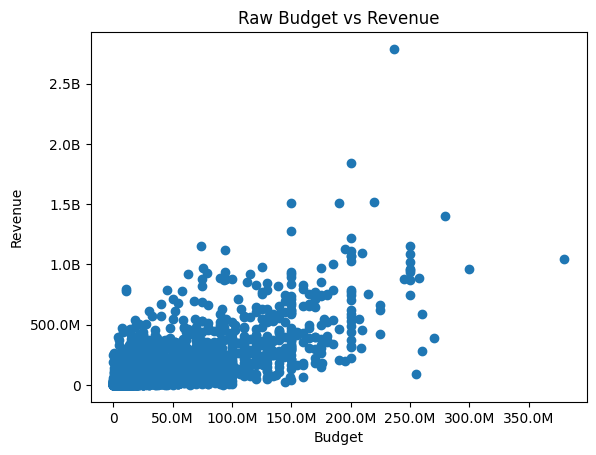

In [40]:
fig, ax = plt.subplots()

ax.scatter(df['budget'], df['revenue'])

format_axes(ax)

ax.set_xlabel('Budget')
ax.set_ylabel('Revenue')
ax.set_title('Raw Budget vs Revenue')

plt.show()

In [35]:
df.describe()

,index,budget,popularity,revenue,runtime,vote_average,vote_count,log_budget,log_revenue
count,3229.000000,3.229000e+03,3229.000000,3.229000e+03,3229.000000,3229.000000,3229.000000,3229.000000,3229.000000
mean,1960.141840,4.065444e+07,29.033689,1.212430e+08,110.724373,6.309353,977.287395,16.799379,17.490816
std,1284.136047,4.439674e+07,36.165730,1.863029e+08,20.965694,0.873891,1414.309577,1.666657,2.081251
min,0.000000,1.000000e+00,0.019984,5.000000e+00,41.000000,0.000000,0.000000,0.000000,1.609438
25%,854.000000,1.050000e+07,10.446722,1.700000e+07,96.000000,5.800000,178.000000,16.166886,16.648724
50%,1815.000000,2.500000e+07,20.410354,5.518472e+07,107.000000,6.300000,471.000000,17.034386,17.826197
75%,2954.000000,5.500000e+07,37.335721,1.462920e+08,121.000000,6.900000,1148.000000,17.822844,18.801115
max,4798.000000,3.800000e+08,875.581305,2.787965e+09,338.000000,8.500000,13752.000000,19.755682,21.748578


In [22]:
df['log_budget'] = np.log(df['budget'])
df['log_revenue'] = np.log(df['revenue'])

A logarithmic transformation was applied to budget and revenue to reduce skewness and better capture the proportional relationship between the variables.

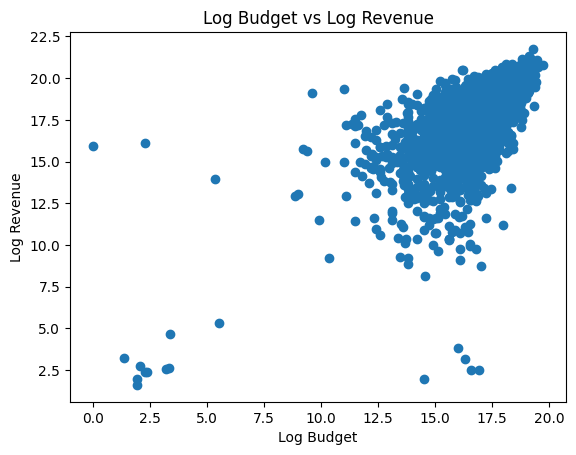

In [41]:
fig, ax = plt.subplots()

ax.scatter(df['log_budget'], df['log_revenue'])

ax.set_xlabel('Log Budget')
ax.set_ylabel('Log Revenue')
ax.set_title('Log Budget vs Log Revenue')

plt.show()

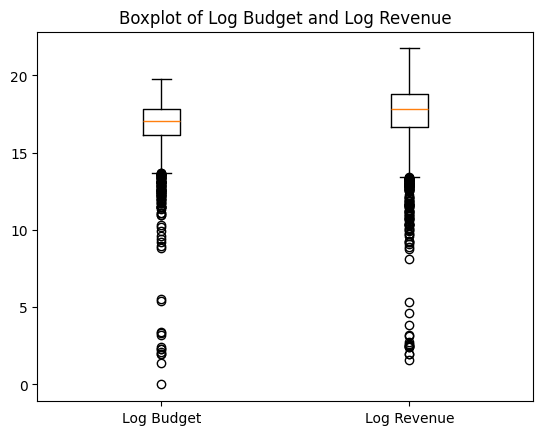

In [43]:
# Detecting outliers
fig, ax = plt.subplots()

ax.boxplot([df['log_budget'], df['log_revenue']])

ax.set_xticklabels(['Log Budget', 'Log Revenue'])
ax.set_title('Boxplot of Log Budget and Log Revenue')

plt.show()

The raw data shows a highly skewed distribution with significant clustering and outliers, making the relationship difficult to interpret. After applying a logarithmic transformation, the data becomes more evenly distributed and reveals a clear positive relationship between budget and revenue.

In [24]:
# Correlation with outliers
correlation = df['log_budget'].corr(df['log_revenue'])
print(correlation) #moderate

0.657083635641743


In [31]:
# Correlation without outliers

q_low = df['log_revenue'].quantile(0.01)
q_high = df['log_revenue'].quantile(0.99)

df_no_outliers = df[(df['log_revenue'] > q_low) & (df['log_revenue'] < q_high)]

df_no_outliers['log_budget'].corr(df_no_outliers['log_revenue'])

np.float64(0.6006073799295873)

Outliers were examined using boxplots and visual inspection. While some extreme values were present, they represent real high-performing films and were retained. The results remained consistent after removing extreme values, indicating that the relationship is robust.

In [25]:
from sklearn.linear_model import LinearRegression

X = df[['log_budget']]
y = df['log_revenue']

model = LinearRegression()
model.fit(X, y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R^2:", model.score(X, y))     # if > 0 support analysis

ModuleNotFoundError: No module named 'sklearn'

In [45]:
import scipy.stats as stats

stats.pearsonr(df['log_budget'], df['log_revenue']) #p < 0.05 significant

PearsonRResult(statistic=np.float64(0.6570836356417425), pvalue=np.float64(0.0))

In [26]:
df['budget_group'] = pd.qcut(df['budget'], 4)
df.groupby('budget_group')['revenue'].mean()

budget_group
(0.999, 10500000.0]          3.045524e+07
(10500000.0, 25000000.0]     6.306122e+07
(25000000.0, 55000000.0]     1.033982e+08
(55000000.0, 380000000.0]    2.939766e+08
Name: revenue, dtype: float64